In [11]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Configuration
DB_PATH = "db/results.sqlite"
sns.set_theme(style="whitegrid", context="paper")

def load_latest_data():
    conn = sqlite3.connect(DB_PATH)
    
    # 1. Robustly find the latest ID (using the logic that worked for you)
    exp_query = "SELECT experiment_id, experiment_name FROM Experiments ORDER BY experiment_id DESC LIMIT 1"
    try:
        latest_exp = pd.read_sql(exp_query, conn).iloc[0]
        latest_id = latest_exp['experiment_id']
        name = latest_exp['experiment_name']
        print(f"Loading LATEST Run: {name} (ID: {latest_id})")
    except Exception as e:
        print("Error finding experiment. Ensure DB is populated.")
        conn.close()
        return None, None

    # 2. Load Results for this ID only
    res_query = f"""
    SELECT 
        r.result_id, r.question_text, r.gold_answer, r.predicted_answer, r.is_correct,
        r.uq_avg_entropy as 'Entropy', r.uq_min_logit_gap as 'LogitGap',
        r.uq_semantic_entropy as 'Semantic', r.uq_heuristic_score as 'Heuristic',
        r.uq_mech_score as 'Mechanistic'
    FROM Results r
    WHERE r.experiment_id = {latest_id} AND r.uq_avg_entropy IS NOT NULL
    """
    df = pd.read_sql(res_query, conn)
    df['Correct'] = df['is_correct'].astype(int)
    
    conn.close()
    return df, latest_id

df, LATEST_EXP_ID = load_latest_data()
print(f"Loaded {len(df)} samples. Accuracy: {df['Correct'].mean():.1%}")

Loading LATEST Run: HUV_DeepSeek_AgentJudge (ID: 24)
Loaded 50 samples. Accuracy: 94.0%


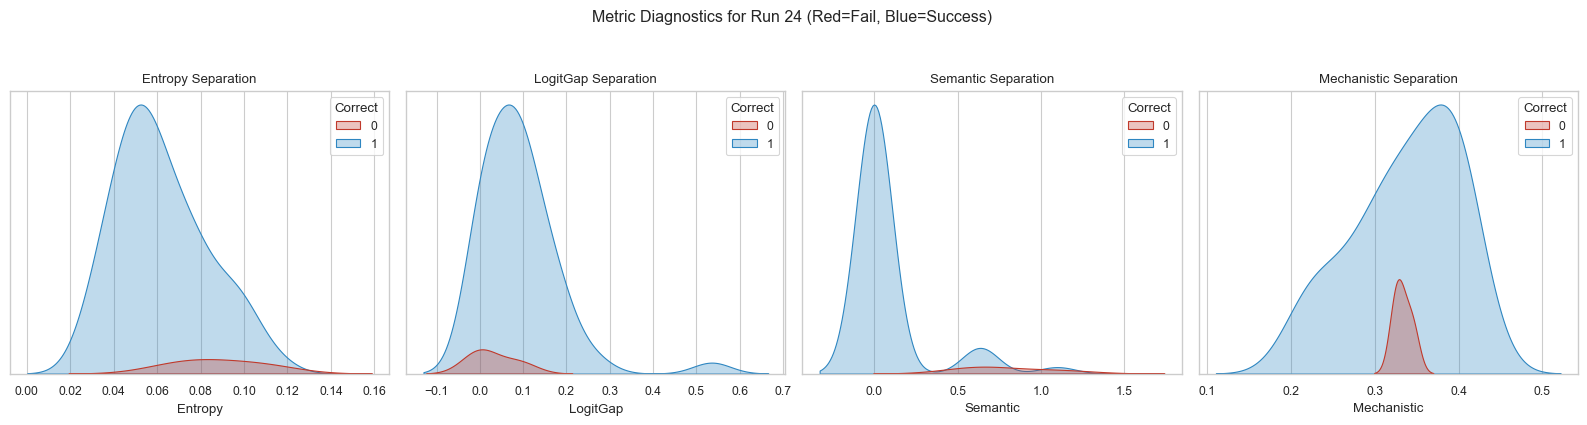

In [13]:
# Select only metrics that have data (variance > 0)
metrics = [m for m in ['Entropy', 'LogitGap', 'Semantic', 'Heuristic', 'Mechanistic'] 
           if df[m].var() > 1e-5]

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
if len(metrics) == 1: axes = [axes]

for i, m in enumerate(metrics):
    # Plot KDE (Smooth Histogram)
    sns.kdeplot(
        data=df, x=m, hue='Correct', 
        fill=True, palette={0: "#C0392B", 1: "#2E86C1"}, 
        alpha=0.3, warn_singular=False, ax=axes[i]
    )
    axes[i].set_title(f"{m} Separation")
    axes[i].set_ylabel("")
    axes[i].get_yaxis().set_ticks([]) # Clean look

plt.suptitle(f"Metric Diagnostics for Run {LATEST_EXP_ID} (Red=Fail, Blue=Success)", y=1.05)
plt.tight_layout()
plt.show()

In [14]:
# import sqlite3
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
# from sklearn.manifold import TSNE

# # --- Configuration ---
# DB_PATH = "db/results.sqlite"
# sns.set_theme(style="whitegrid", context="paper")
# PALETTE = {0: "#E74C3C", 1: "#2ECC71"}  # Red for Incorrect, Green for Correct

# def load_latest_data():
#     """Loads data specifically for the most recent experiment ID."""
#     conn = sqlite3.connect(DB_PATH)
    
#     # 1. Find Latest Experiment
#     try:
#         exp_query = "SELECT experiment_id, experiment_name FROM Experiments ORDER BY experiment_id DESC LIMIT 1"
#         latest_exp = pd.read_sql(exp_query, conn).iloc[0]
#         latest_id = latest_exp['experiment_id']
#         name = latest_exp['experiment_name']
#         print(f"--- Loading Experiment: {name} (ID: {latest_id}) ---")
#     except Exception as e:
#         print("Error finding experiment. Ensure DB is populated.")
#         conn.close()
#         return None, None

#     # 2. Load Results
#     res_query = f"""
#     SELECT 
#         r.result_id, 
#         r.is_correct,
#         r.uq_avg_entropy as 'Entropy', 
#         r.uq_min_logit_gap as 'LogitGap',
#         r.uq_semantic_entropy as 'Semantic', 
#         r.uq_heuristic_score as 'Heuristic',
#         r.uq_mech_score as 'Mechanistic'
#     FROM Results r
#     WHERE r.experiment_id = {latest_id} 
#       AND r.uq_avg_entropy IS NOT NULL
#       AND r.uq_mech_score IS NOT NULL
#     """
#     df = pd.read_sql(res_query, conn)
#     df['Correct'] = df['is_correct'].astype(int)
    
#     conn.close()
#     return df, latest_id

# def plot_correlation_matrix(df):
#     """Plots the heatmap of correlations between metrics."""
#     plt.figure(figsize=(10, 8))
    
#     # Select only numeric metric columns
#     metrics = ['Entropy', 'LogitGap', 'Semantic', 'Heuristic', 'Mechanistic', 'Correct']
#     corr = df[metrics].corr()
    
#     mask = np.triu(np.ones_like(corr, dtype=bool))
#     sns.heatmap(corr, mask=mask, cmap="vlag", center=0, annot=True, fmt=".2f",
#                 linewidths=.5, cbar_kws={"shrink": .5})
    
#     plt.title("Metric Correlation Matrix", fontsize=16)
#     plt.tight_layout()
#     plt.show()

# def plot_pairwise_grid(df):
#     """
#     Plots every metric against every other metric, 
#     colored by Correctness. This is the 'Bird's Eye View'.
#     """
#     metrics = ['Entropy', 'LogitGap', 'Mechanistic', 'Heuristic']
    
#     # Create the PairGrid
#     g = sns.pairplot(
#         df, 
#         vars=metrics, 
#         hue='Correct', 
#         palette=PALETTE,
#         diag_kind="kde",
#         plot_kws={'alpha': 0.6, 's': 30},
#         height=2.5
#     )
    
#     g.fig.suptitle("Pairwise Relationships: Metrics vs. Correctness", y=1.02, fontsize=16)
#     plt.show()

# def plot_tsne_clusters(df):
#     """
#     Uses t-SNE to reduce the dimensions to 2D.
#     This helps find 'types' of answers (e.g. Confident Wrong, Rote Right).
#     """
#     print("Running t-SNE (this might take a moment)...")
    
#     features = ['Entropy', 'LogitGap', 'Mechanistic', 'Heuristic', 'Semantic']
    
#     # Drop rows with NaNs in these columns to avoid errors
#     data_for_tsne = df[features].dropna()
    
#     # Standardize features (Mean=0, Std=1)
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(data_for_tsne)
    
#     # Run t-SNE
#     tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
#     X_embedded = tsne.fit_transform(X_scaled)
    
#     # Create temp dataframe for plotting
#     plot_df = pd.DataFrame(X_embedded, columns=['x', 'y'])
#     plot_df['Correct'] = df.loc[data_for_tsne.index, 'Correct']
#     plot_df['Mechanistic'] = df.loc[data_for_tsne.index, 'Mechanistic']
    
#     # Plot
#     fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
#     # Left: Colored by Correctness
#     sns.scatterplot(data=plot_df, x='x', y='y', hue='Correct', palette=PALETTE, alpha=0.7, ax=axes[0])
#     axes[0].set_title("t-SNE Map: Answer Correctness", fontsize=14)
    
#     # Right: Colored by Mechanistic Score (to see where the "hard thinking" happens)
#     scatter = axes[1].scatter(plot_df['x'], plot_df['y'], c=plot_df['Mechanistic'], cmap='viridis', alpha=0.7)
#     axes[1].set_title("t-SNE Map: Mechanistic Intensity", fontsize=14)
#     plt.colorbar(scatter, ax=axes[1], label='Mechanistic Score')
    
#     plt.suptitle("Latent Manifold of Reasoning Traces", fontsize=18)
#     plt.tight_layout()
#     plt.show()

# # --- Main Execution ---
# if __name__ == "__main__":
#     df, exp_id = load_latest_data()
    
#     if df is not None and len(df) > 0:
#         print(f"Loaded {len(df)} samples from Experiment {exp_id}")
#         print(f"Global Accuracy: {df['Correct'].mean():.2%}")
        
#         # 1. The Heatmap
#         plot_correlation_matrix(df)
        
#         # 2. The Pairplot (The "Everything" Plot)
#         plot_pairwise_grid(df)
        
#         # 3. The Cluster Map
#         plot_tsne_clusters(df)
#     else:
#         print("No data found.")

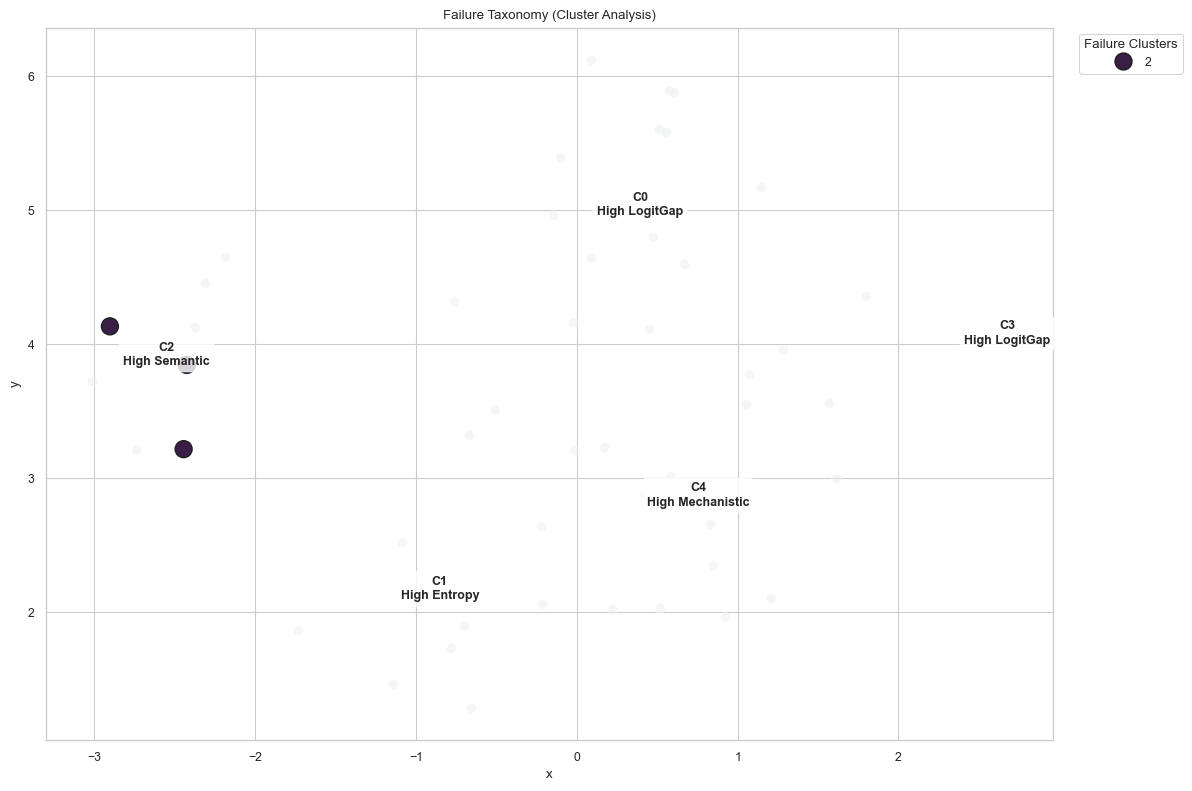

In [15]:
# 1. Prepare Features
features = ['Entropy', 'LogitGap', 'Semantic', 'Heuristic', 'Mechanistic']
X = StandardScaler().fit_transform(df[features].fillna(0))

# 2. Cluster
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# 3. Project (t-SNE)
tsne = TSNE(n_components=2, perplexity=min(30, len(df)-1), random_state=42, init='pca')
proj = tsne.fit_transform(X)
df['x'], df['y'] = proj[:, 0], proj[:, 1]

# 4. Plot
plt.figure(figsize=(12, 8))

# Background: Correct (Grey Ghost)
sns.scatterplot(data=df[df['Correct']==1], x='x', y='y', color='#ecf0f1', s=50, alpha=0.5)

# Foreground: Failures (Colored by Type)
sns.scatterplot(
    data=df[df['Correct']==0], x='x', y='y', 
    hue='Cluster', palette='turbo', style='Cluster',
    s=150, alpha=0.95, edgecolor='k'
)

# Label Centroids
for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    if sub.empty: continue
    
    # Identify the defining characteristic of this cluster
    z_scores = (sub[features].mean() - df[features].mean()) / df[features].std()
    tag = z_scores.idxmax() 
    
    center = sub[['x', 'y']].mean()
    plt.text(
        center['x'], center['y'], 
        f"C{c}\nHigh {tag}", 
        ha='center', va='center', fontweight='bold', fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
    )

plt.title(f"Failure Taxonomy (Cluster Analysis)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Failure Clusters")
plt.tight_layout()
plt.show()

/var/folders/q0/hw11rnjs0g1cnny7p5swsnv40000gn/T/ipykernel_33804/3453780896.py:35: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/sadigulcelik/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


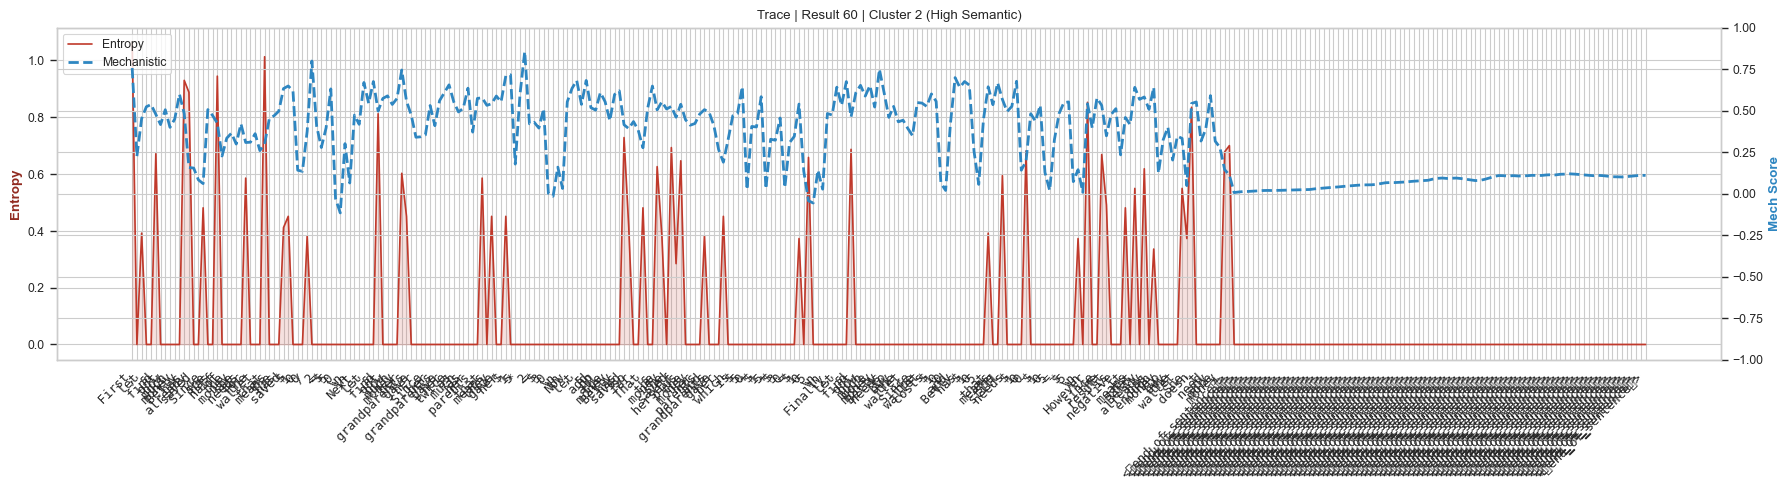

In [16]:
def plot_trace(result_id):
    conn = sqlite3.connect(DB_PATH)
    trace = pd.read_sql(
        f"SELECT token_text, entropy, logit_gap, mechanistic_score FROM Token_Metrics WHERE result_id = {result_id} ORDER BY position", 
        conn
    )
    conn.close()
    
    if trace.empty: return print("No token data found.")

    fig, ax1 = plt.subplots(figsize=(18, 5))
    
    # Entropy (Red Fill)
    ax1.fill_between(range(len(trace)), 0, trace['entropy'], color='#C0392B', alpha=0.15)
    ax1.plot(trace['entropy'], color='#C0392B', label='Entropy')
    ax1.set_ylabel('Entropy', color='#922B21', fontweight='bold')
    
    # Mechanistic (Blue Line)
    ax2 = ax1.twinx()
    ax2.plot(trace['mechanistic_score'], color='#2E86C1', linewidth=2, linestyle='--', label='Mechanistic')
    ax2.set_ylabel('Mech Score', color='#2E86C1', fontweight='bold')
    ax2.set_ylim(-1, 1)

    # X-Axis
    ax1.set_xticks(range(len(trace)))
    ax1.set_xticklabels(trace['token_text'], rotation=45, ha='right', fontsize=9, fontfamily='monospace')
    
    # Combined Legend
    lines1, l1 = ax1.get_legend_handles_labels()
    lines2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, l1 + l2, loc='upper left')
    
    info = df[df['result_id'] == result_id].iloc[0]
    plt.title(f"Trace | Result {str(result_id)} | Cluster {str(info['Cluster'])} (High {features[int(info['Cluster'])] if 'Cluster' in info else '?'})")
    plt.tight_layout()
    plt.show()

# Pick a failure from the largest cluster
if len(df[df['Correct']==0]) > 0:
    worst_cluster = df[df['Correct']==0]['Cluster'].value_counts().idxmax()
    sample_id = df[(df['Cluster'] == worst_cluster) & (df['Correct'] == 0)].iloc[0]['result_id']
    plot_trace(sample_id)
else:
    print("No failures to inspect.")

In [21]:
from IPython.display import display, HTML
import sqlite3
import pandas as pd
import numpy as np
import html  # Added for safety

DB_PATH = "db/results.sqlite"

# --- CONFIGURATION: PER-METRIC THRESHOLDS ---
# 'flag':  Z-Score to trigger Orange Label
# 'split': Z-Score to trigger Red Label + New Section (Break BEFORE token)

THRESHOLDS = {
    'entropy':     {'flag': 13.0, 'split': 14.5}, # Entropy usually needs a higher ceiling to signal a true break
    'mechanistic': {'flag': 1.5, 'split': 2.0},
    'logit_gap':   {'flag': 13.0, 'split': 14.5}
}

def fix_bpe_artifacts(text):
    """
    Fixes common BPE visualization artifacts and encoding glitches.
    """
    # 1. Standard GPT/RoBERTa BPE markers
    text = text.replace('Ġ', ' ').replace('Ċ', '\n').replace('<0x0A>', '\n')
    
    # 2. Fix Common Mojibake (UTF-8 bytes displayed as Latin-1)
    # âĢĻ -> ’ (Right single quote)
    # âĢĵ -> – (En dash)
    # âĢĶ -> ... (Ellipsis)
    # âĢľ -> “ (Left double quote)
    # âĢĿ -> ” (Right double quote)
    replacements = {
        'âĢĻ': "'", 'âĢĵ': "–", 'âĢĶ': "...", 
        'âĢľ': '"', 'âĢĿ': '"', 'âĹ': '-'
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
        
    return text

def clean_tokens(df):
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['entropy', 'mechanistic_score'])
    eos_pattern = r'<[\|｜]end.*?[\|｜]>|</s>|<eos>|<pad>|<\|eot_id\|>'
    eos_matches = df[df['token_text'].str.contains(eos_pattern, regex=True, na=False)]
    if not eos_matches.empty:
        first_eos_idx = eos_matches.index[0]
        df = df.loc[:first_eos_idx-1]
    return df.reset_index(drop=True)

def process_case(row):
    result_id = row['result_id']
    
    with sqlite3.connect(DB_PATH) as conn:
        trace = pd.read_sql(
            f"SELECT token_text, entropy, logit_gap, mechanistic_score FROM Token_Metrics WHERE result_id = {result_id} ORDER BY position", 
            conn
        )
    
    if trace.empty: return
    trace = clean_tokens(trace)
    
    trace['inv_logit_gap'] = -trace['logit_gap']
    
    # Calculate Z-Scores
    cols_map = {'entropy': 'entropy', 'mechanistic': 'mechanistic_score', 'logit_gap': 'inv_logit_gap'}
    
    for metric_name, db_col in cols_map.items():
        mu, sigma = trace[db_col].mean(), trace[db_col].std()
        if sigma == 0: sigma = 1e-6
        trace[f'z_{metric_name}'] = (trace[db_col] - mu) / sigma

    sections = []       
    current_block = []  
    
    for _, t_row in trace.iterrows():
        # 1. Clean and Escape Text
        raw_txt = fix_bpe_artifacts(t_row['token_text'])
        # HTML escape ensures < or > in math don't break the div
        display_txt = html.escape(raw_txt).replace('\n', '<br>')
        
        # 2. Check Metrics against specific thresholds
        z_ent = t_row['z_entropy']
        z_mech = t_row['z_mechanistic']
        z_gap = t_row['z_logit_gap']
        
        # Determine status per metric
        ent_status = 'split' if z_ent > THRESHOLDS['entropy']['split'] else ('flag' if z_ent > THRESHOLDS['entropy']['flag'] else 'ok')
        mech_status = 'split' if z_mech > THRESHOLDS['mechanistic']['split'] else ('flag' if z_mech > THRESHOLDS['mechanistic']['flag'] else 'ok')
        gap_status = 'split' if z_gap > THRESHOLDS['logit_gap']['split'] else ('flag' if z_gap > THRESHOLDS['logit_gap']['flag'] else 'ok')
        
        # Overall status (Split takes precedence over Flag)
        is_split = 'split' in [ent_status, mech_status, gap_status]
        is_flag = 'flag' in [ent_status, mech_status, gap_status] or is_split
        
        token_html = f"<span>{display_txt}</span>"
        
        if is_flag:
            lbls = []
            # Only show labels for the specific metrics that triggered
            if z_ent > THRESHOLDS['entropy']['flag']: lbls.append(f"Ent:{z_ent:.1f}")
            if z_mech > THRESHOLDS['mechanistic']['flag']: lbls.append(f"Mech:{z_mech:.1f}")
            if z_gap > THRESHOLDS['logit_gap']['flag']: lbls.append(f"Gap:{z_gap:.1f}")
            
            stats_str = " | ".join(lbls)
            
            color = "#C0392B" if is_split else "#D35400"
            weight = "bold" if is_split else "normal"
            
            token_html += f"<span style='color:{color}; font-weight:{weight}; font-size:0.75em; margin-left:2px; vertical-align:super;'>[{stats_str}]</span>"
            
            if is_split:
                # Flush BEFORE this token to isolate the high-uncertainty event
                if current_block:
                    sections.append("".join(current_block))
                    current_block = [] 
                
                current_block.append(token_html)
            else:
                current_block.append(token_html)
        else:
            current_block.append(token_html)

    if current_block:
        sections.append("".join(current_block))

    divider = "<div style='margin: 15px 0; border-bottom: 1px dashed #bbb;'></div>"
    full_html = divider.join([f"<div>{s}</div>" for s in sections if s.strip()]) 
    
    status_color = "#2E86C1" if row['Correct'] else "#C0392B"
    status_text = "CORRECT" if row['Correct'] else "INCORRECT"
    
    display(HTML(f"""
    <div style="border:1px solid #ccc; margin-bottom:30px; padding:20px; font-family:monospace; background:white;">
        <div style="border-bottom:1px solid #eee; padding-bottom:10px; margin-bottom:15px; font-weight:bold; font-size:1.1em; color:#333;">
            Case ID: {result_id} | <span style="color:{status_color}">{status_text}</span>
        </div>

        <div style="background-color:#f8f9fa; border-left:4px solid #aaa; padding:10px 15px; margin-bottom:20px; color:#444; font-size:0.95em;">
            <div style="margin-bottom:8px;">
                <strong>Question:</strong><br>
                {html.escape(row['question_text']).replace(chr(10), '<br>')}
            </div>
            <div>
                <strong>Gold Answer:</strong> <code>{row['gold_answer']}</code>
            </div>
        </div>

        <div style="line-height:1.6; color:#222; font-size:1.0em;">
            {full_html}
        </div>
    </div>
    """))

print(f"Auditing {len(df)} cases from Experiment {LATEST_EXP_ID}...\n")
for i, row in df.iterrows():
    process_case(row)

Auditing 50 cases from Experiment 24...



In [10]:
row

result_id      58.000000
is_correct      1.000000
Entropy         0.060476
LogitGap        0.044647
Semantic        0.000000
Heuristic       0.000000
Mechanistic     0.303223
Correct         1.000000
Cluster         0.000000
x              -0.023659
y               4.168421
Name: 0, dtype: float64

In [ ]:
# import sqlite3
# import pandas as pd
# import numpy as np
# from openai import OpenAI
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from tqdm import tqdm
# import json
# import re
# import os
# import sys

# # --- CONFIGURATION ---
# OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
# if not OPENAI_API_KEY:
#     print("Error: OPENAI_API_KEY not found in environment variables.")
#     sys.exit(1)

# DB_PATH = "db/results.sqlite"
# TABLE_NAME = "Results"
# MODEL = "gpt-4o" 
# LOG_FILE = "gpt_inputs.log"

# client = OpenAI(api_key=OPENAI_API_KEY)

# # --- TEXT RECONSTRUCTION HELPERS ---

# def fix_bpe_artifacts(text):
#     """
#     Fixes common BPE visualization artifacts and encoding glitches.
#     """
#     if not isinstance(text, str): return ""
    
#     # 1. Standard GPT/RoBERTa BPE markers
#     text = text.replace('Ġ', ' ').replace('Ċ', '\n').replace('<0x0A>', '\n')
    
#     # 2. Fix Common Mojibake (UTF-8 bytes displayed as Latin-1)
#     replacements = {
#         'âĢĻ': "'", 'âĢĵ': "–", 'âĢĶ': "...", 
#         'âĢľ': '"', 'âĢĿ': '"', 'âĹ': '-'
#     }
#     for bad, good in replacements.items():
#         text = text.replace(bad, good)
        
#     return text

# def get_full_text_from_tokens(result_id):
#     """
#     Reconstructs the full text from Token_Metrics for a specific result_id.
#     """
#     try:
#         # Use a new connection per thread/call to avoid concurrency issues
#         with sqlite3.connect(DB_PATH) as conn:
#             query = f"""
#                 SELECT token_text 
#                 FROM Token_Metrics 
#                 WHERE result_id = {result_id} 
#                 ORDER BY position
#             """
#             df = pd.read_sql(query, conn)
            
#         if df.empty:
#             return None

#         # Filter out EOS tokens and subsequent padding
#         eos_pattern = r'<[\|｜]end.*?[\|｜]>|</s>|<eos>|<pad>|<\|eot_id\|>'
#         eos_matches = df[df['token_text'].str.contains(eos_pattern, regex=True, na=False)]
        
#         if not eos_matches.empty:
#             first_eos_idx = eos_matches.index[0]
#             df = df.loc[:first_eos_idx-1]
            
#         # Reconstruct text
#         full_text = "".join([fix_bpe_artifacts(t) for t in df['token_text']])
#         return full_text.strip()

#     except Exception as e:
#         # Fail silently and return None so we fallback to other columns
#         return None

# def clean_json_text(text):
#     """
#     Removes markdown formatting like ```json ... ``` to ensure valid JSON parsing.
#     """
#     text = text.strip()
#     if text.startswith("```"):
#         text = re.sub(r"^```(json)?", "", text, flags=re.IGNORECASE)
#         text = text.rstrip("`")
#     return text.strip()

# def get_latest_experiment_id(cursor):
#     try:
#         cursor.execute("SELECT experiment_id, experiment_name FROM Experiments ORDER BY experiment_id DESC LIMIT 1")
#         row = cursor.fetchone()
#         if row:
#             print(f"Targeting Experiment: {row[1]} (ID: {row[0]})")
#             return row[0]
#         else:
#             print("No experiments found.")
#             return None
#     except Exception as e:
#         print(f"Error fetching experiment ID: {e}")
#         return None

# def get_gpt_verdict(row):
#     q_text = row.get('question_text', '')
#     gold = row.get('gold_answer', '')
#     row_id = row.get('result_id')

#     # 1. Attempt to reconstruct full text from Token_Metrics (Most Accurate)
#     model_out = get_full_text_from_tokens(row_id)

#     # 2. Fallback to Results table columns if token reconstruction fails
#     if not model_out:
#         model_out = row.get('response_text')
#         if not model_out or pd.isna(model_out):
#             model_out = row.get('predicted_answer', '')

#     prompt = f"""
#     You are an automated evaluator for a dataset.
    
#     Question: {q_text}
    
#     Gold Answer (Ground Truth): {gold}
    
#     Model Full Response: {model_out}
    
#     TASK: Determine if the Model's response arrives at the correct answer.
#     1. Read the "Model Full Response" to find the final answer.
#     2. Compare it to the "Gold Answer".
#     3. Ignore minor formatting (e.g., "$5" vs "5 dollars").
#     4. If the reasoning is correct but the final labeled answer is wrong, it is INCORRECT.
#     5. If the logic is fundamentally flawed, it is INCORRECT.
    
#     Return JSON format: {{ "is_correct": boolean, "reason": "short explanation" }}
#     """

#     # --- LOG PROMPT TO FILE ---
#     try:
#         with open(LOG_FILE, "a", encoding="utf-8") as f:
#             f.write(f"=== ID: {row_id} ===\n{prompt}\n{'='*30}\n\n")
#     except Exception as e:
#         print(f"Logging error for ID {row_id}: {e}")
#     # --------------------------

#     try:
#         response = client.chat.completions.create(
#             model=MODEL,
#             messages=[
#                 {"role": "system", "content": "You are a strict evaluator. Output valid JSON only."},
#                 {"role": "user", "content": prompt}
#             ],
#             response_format={"type": "json_object"},
#             temperature=0.0
#         )
        
#         raw_content = response.choices[0].message.content
#         clean_content = clean_json_text(raw_content)
#         content = json.loads(clean_content)
        
#         # --- PRINT RESULT TO CONSOLE ---
#         is_cor = content.get("is_correct")
#         reason = content.get("reason")
#         tqdm.write(f"[ID: {row_id}] Correct: {is_cor} | Reason: {reason}")
#         # -------------------------------

#         return {
#             "result_id": row_id,
#             "new_correct": 1 if is_cor else 0,
#             "reason": reason,
#             "status": "success"
#         }
#     except Exception as e:
#         return {"result_id": row_id, "status": "error", "reason": str(e)}

# def main():
#     # Initialize Log File
#     with open(LOG_FILE, "w", encoding="utf-8") as f:
#         f.write("--- GPT Evaluation Log ---\n\n")

#     conn = sqlite3.connect(DB_PATH)
#     cursor = conn.cursor()

#     # --- STEP 1: SCOPE ---
#     latest_exp_id = get_latest_experiment_id(cursor)
#     if latest_exp_id is None:
#         conn.close()
#         return

#     # --- STEP 2: BACKUP ---
#     print("Step 2: verifying backup column...")
#     try:
#         cursor.execute(f"ALTER TABLE {TABLE_NAME} ADD COLUMN old_is_correct INTEGER")
#         print("Created 'old_is_correct' column.")
#         cursor.execute(f"UPDATE {TABLE_NAME} SET old_is_correct = is_correct WHERE experiment_id = ?", (latest_exp_id,))
#         conn.commit()
#     except sqlite3.OperationalError:
#         print("'old_is_correct' column already exists. Skipping backup overwrite.")

#     # --- STEP 3: LOAD DATA ---
#     print(f"Step 3: Loading results for Experiment ID {latest_exp_id}...")
    
#     try:
#         query = f"""
#             SELECT result_id, question_text, gold_answer, predicted_answer, response_text 
#             FROM {TABLE_NAME} 
#             WHERE experiment_id = {latest_exp_id}
#         """
#         df = pd.read_sql(query, conn)
#     except Exception as e:
#         print(f"Error loading columns: {e}")
#         print("Attempting fallback without 'response_text'...")
#         query = f"""
#             SELECT result_id, question_text, gold_answer, predicted_answer 
#             FROM {TABLE_NAME} 
#             WHERE experiment_id = {latest_exp_id}
#         """
#         df = pd.read_sql(query, conn)

#     conn.close()
    
#     print(f"Found {len(df)} rows. Starting evaluation with {MODEL}...")

#     results = []
    
#     # --- STEP 4: EXECUTE ---
#     with ThreadPoolExecutor(max_workers=10) as executor:
#         futures = [executor.submit(get_gpt_verdict, row) for _, row in df.iterrows()]
#         for future in tqdm(as_completed(futures), total=len(futures), desc="Evaluating"):
#             results.append(future.result())

#     # --- STEP 5: UPDATE ---
#     print("Step 5: Updating database...")
#     conn = sqlite3.connect(DB_PATH)
#     cursor = conn.cursor()
    
#     try:
#         cursor.execute(f"ALTER TABLE {TABLE_NAME} ADD COLUMN gpt_eval_reason TEXT")
#     except sqlite3.OperationalError:
#         pass 

#     updates = []
#     errors = []
#     for res in results:
#         if res['status'] == 'success':
#             updates.append((res['new_correct'], res['reason'], res['result_id']))
#         else:
#             errors.append(res['reason'])
    
#     if updates:
#         cursor.executemany(
#             f"UPDATE {TABLE_NAME} SET is_correct = ?, gpt_eval_reason = ? WHERE result_id = ?", 
#             updates
#         )
#         conn.commit()
#         print(f"Successfully updated {len(updates)} rows.")
#     else:
#         print("WARNING: 0 rows updated.")
#         if errors:
#             print(f"First Error encountered: {errors[0]}")
#             print(f"Total Errors: {len(errors)}")

#     conn.close()

# if __name__ == "__main__":
#     main()